## **Modelagem Preditiva — Evasão Escolar**

**Objetivo:** Treinar e comparar modelos capazes de identificar alunos em risco de evasão, priorizando **Recall** — intenção é errar menos por falta (falso negativo = deixar um aluno em risco sem apoio).

### Pipeline
```
Dados brutos:
    - Feature Engineering
    - Pré-processamento (encoding + scaling)
    - Divisão treino/teste (stratify)
    - SMOTE apenas no treino
    - Treinamento: Baseline (LR), Random Forest, XGBoost
    - Tuning de Threshold otimizado para F2-Score
    - Avaliação e comparação
    - Salvamento do modelo final
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing      import StandardScaler, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, fbeta_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling     import SMOTE
from imblearn.pipeline          import Pipeline as ImbPipeline
from xgboost                    import XGBClassifier

# Caminhos
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
MODELS_DIR  = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# Estilo
COLOR_MAIN   = '#2C3E50'
COLOR_ACCENT = '#E74C3C'
COLOR_OK     = '#2ECC71'
COLOR_XGB    = '#F39C12'
COLOR_RF     = '#3498DB'
COLOR_LR     = '#9B59B6'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def save_fig(name: str):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')

## **Carregar dados e Feature Engineering:**

In [2]:
df = pd.read_csv(DATA_DIR / 'evasao_escolar.csv')
print(f'Shape: {df.shape}  |  Evasão: {df["evasao"].mean():.1%}')

# Feature Engineering
df['media_notas']       = (df['nota_portugues'] + df['nota_matematica']) / 2
df['baixo_desempenho']  = ((df['nota_portugues'] < 5) | (df['nota_matematica'] < 5)).astype(int)
df['risco_faltas']      = (df['faltas_anuais'] > 15).astype(int)
df['risco_distorcao']   = (df['distorcao_idade_serie'] >= 2).astype(int)
df['engajamento']       = df['media_notas'] / (df['faltas_anuais'] + 1)  # evita div/0

# Separar features e target
NUM_FEATURES = [
    'idade', 'nota_portugues', 'nota_matematica', 'media_notas',
    'distorcao_idade_serie', 'faltas_anuais', 'repeticoes_anteriores',
    'renda_familiar', 'trabalha', 'escolaridade_pai', 'escolaridade_mae',
    'baixo_desempenho', 'risco_faltas', 'risco_distorcao', 'engajamento'
]
CAT_FEATURES = ['serie', 'turno', 'sexo', 'raca_cor']
TARGET       = 'evasao'

X = df[NUM_FEATURES + CAT_FEATURES]
y = df[TARGET]

print(f'Features numéricas : {len(NUM_FEATURES)}')
print(f'Features categóricas: {len(CAT_FEATURES)}')

Shape: (15000, 15)  |  Evasão: 26.5%
Features numéricas : 15
Features categóricas: 4


---
## **Divisão Treino / Teste**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # mantém proporção de evasão em treino e teste
)

print(f'Treino : {X_train.shape[0]:,} amostras  |  Evasão: {y_train.mean():.1%}')
print(f'Teste  : {X_test.shape[0]:,} amostras  |  Evasão: {y_test.mean():.1%}')

Treino : 12,000 amostras  |  Evasão: 26.5%
Teste  : 3,000 amostras  |  Evasão: 26.5%


## **Pré-processamento e Pipelines com SMOTE:**

In [4]:
# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
])

# Pipelines com SMOTE (imbalanced-learn)
pipelines = {
    'Logistic Regression (baseline)': ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                     class_weight='balanced')),
    ]),
    'Random Forest': ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   RandomForestClassifier(n_estimators=200, max_depth=15,
                                         min_samples_leaf=5,
                                         class_weight='balanced',
                                         random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    'XGBoost': ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   XGBClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=6, subsample=0.8,
                                colsample_bytree=0.8,
                                scale_pos_weight=4,        # peso pela proporção de classes
                                eval_metric='logloss',
                                random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

print('Pipelines criados:', list(pipelines.keys()))

Pipelines criados: ['Logistic Regression (baseline)', 'Random Forest', 'XGBoost']


## **Treinamento e Cross-Validation:**

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'recall', 'f1', 'precision']

cv_results = {}
modelos_treinados = {}

for nome, pipe in pipelines.items():
    print(f'Treinando: {nome}...')
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1)
    cv_results[nome] = scores
    # Treinar no conjunto completo de treino para avaliar no teste
    pipe.fit(X_train, y_train)
    modelos_treinados[nome] = pipe
    print(f'  AUC-ROC cv: {scores["test_roc_auc"].mean():.4f} ± {scores["test_roc_auc"].std():.4f}')
    print(f'  Recall  cv: {scores["test_recall"].mean():.4f} ± {scores["test_recall"].std():.4f}')
    print()

Treinando: Logistic Regression (baseline)...
  AUC-ROC cv: 0.9325 ± 0.0050
  Recall  cv: 0.8401 ± 0.0175

Treinando: Random Forest...
  AUC-ROC cv: 0.9652 ± 0.0044
  Recall  cv: 0.8546 ± 0.0067

Treinando: XGBoost...
  AUC-ROC cv: 0.9662 ± 0.0035
  Recall  cv: 0.9119 ± 0.0108



## **Tuning de Threshold:**

O threshold padrão (0.50) não é ideal para problemas desbalanceados onde o custo do falso negativo é alto. Usei o **F2-Score** (que pesa recall 2× mais que precision) para encontrar o threshold ótimo.

In [7]:
def threshold_otimo_f2(y_true, y_proba) -> tuple[float, float]:
    """
    Retorna (threshold, f2_score) que maximiza F2 no conjunto fornecido.
    F2 = (1+4) * precision * recall / (4*precision + recall)
    """
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    f2 = (5 * prec * rec) / (4 * prec + rec + 1e-9)
    idx  = np.argmax(f2[:-1])   # último elemento não tem threshold correspondente
    return float(thresholds[idx]), float(f2[idx])


thresholds = {}
for nome, pipe in modelos_treinados.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    thr, f2 = threshold_otimo_f2(y_test, y_proba)
    thresholds[nome] = thr
    print(f'{nome}  -  threshold ótimo: {thr:.3f}  |  F2: {f2:.4f}')

Logistic Regression (baseline)  -  threshold ótimo: 0.385  |  F2: 0.8187
Random Forest  -  threshold ótimo: 0.314  |  F2: 0.8772
XGBoost  -  threshold ótimo: 0.382  |  F2: 0.8833


## **Avaliação Final no Conjunto de Teste:**

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []
predicoes  = {}

for nome, pipe in modelos_treinados.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= thresholds[nome]).astype(int)
    predicoes[nome] = {'proba': y_proba, 'pred': y_pred}

    resultados.append({
        'Modelo'    : nome,
        'Threshold' : round(thresholds[nome], 3),
        'Acurácia'  : round(accuracy_score(y_test, y_pred), 4),
        'Precisão'  : round(precision_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred), 4),
        'F2-Score'  : round(fbeta_score(y_test, y_pred, beta=2), 4),
        'AUC-ROC'   : round(roc_auc_score(y_test, y_proba), 4),
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

                        Modelo  Threshold  Acurácia  Precisão  Recall  F1-Score  F2-Score  AUC-ROC
Logistic Regression (baseline)      0.385    0.8083    0.5897  0.9068    0.7146    0.8187   0.9302
                 Random Forest      0.314    0.8763    0.6986  0.9370    0.8004    0.8772   0.9683
                       XGBoost      0.382    0.8703    0.6826  0.9534    0.7956    0.8833   0.9702


---
## 7 · Gráfico de Comparação de Métricas

Salvo: ..\figures\07_comparacao_modelos.png


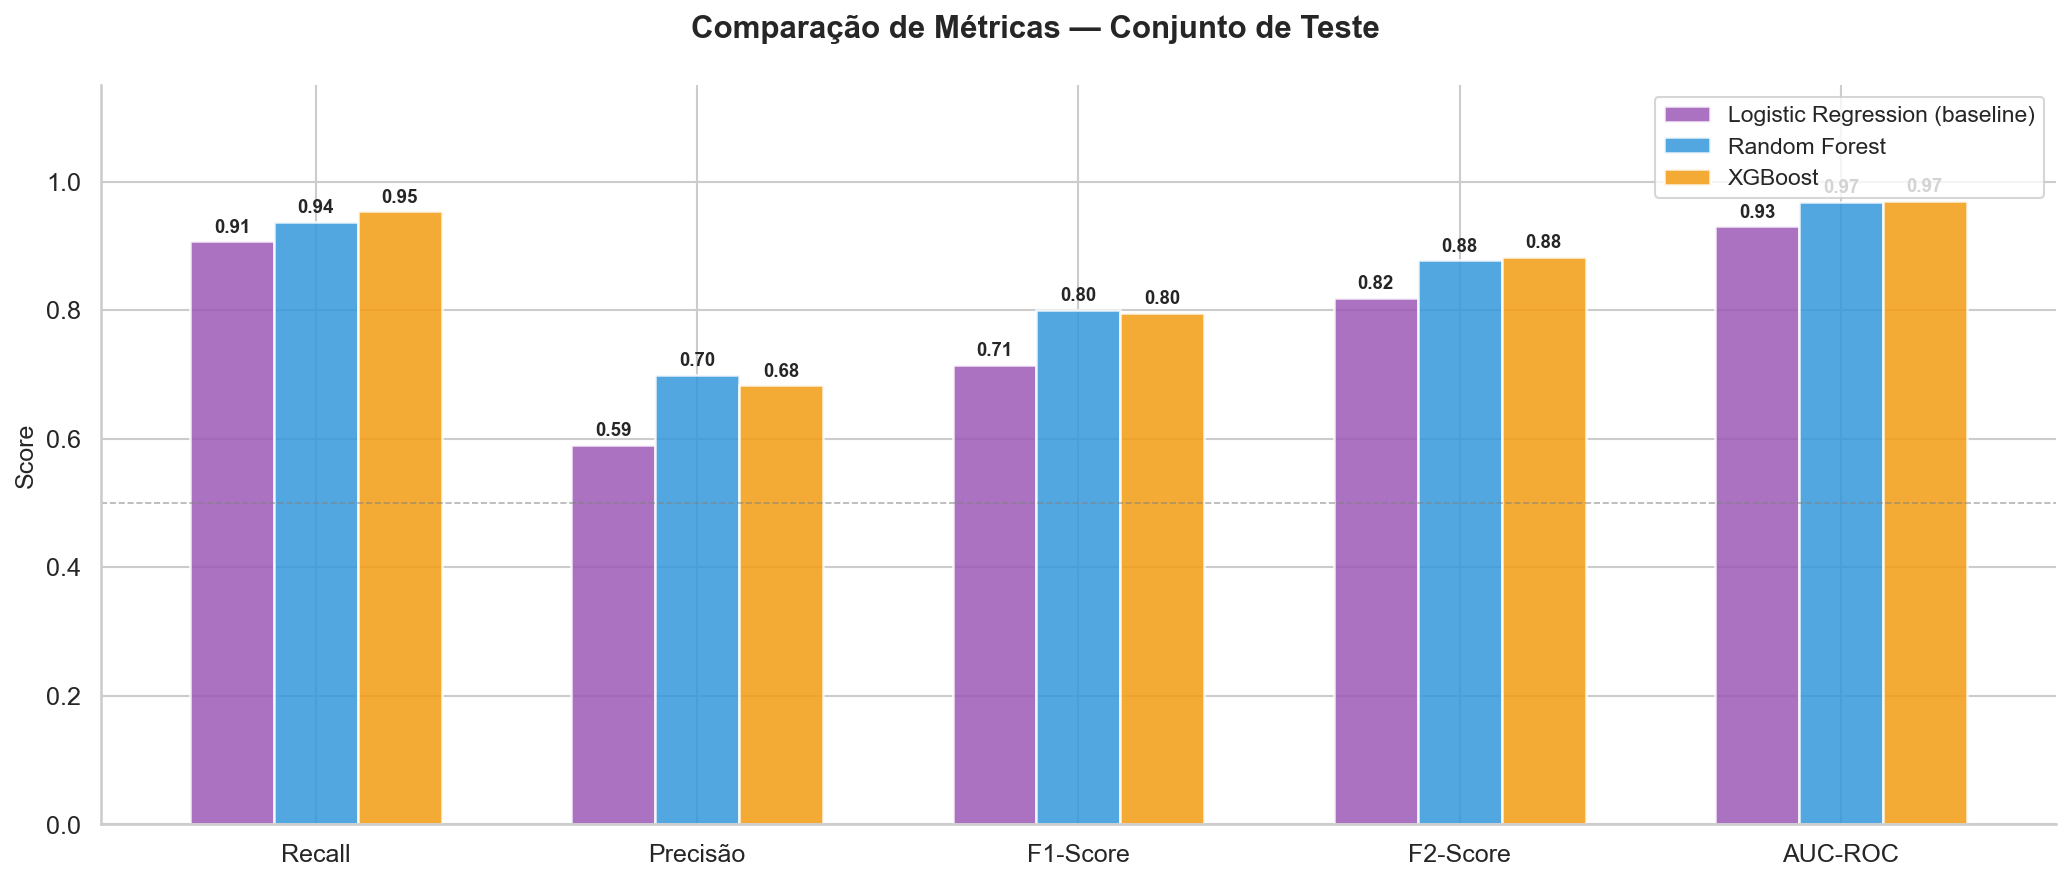

In [9]:
metricas_plot = ['Recall', 'Precisão', 'F1-Score', 'F2-Score', 'AUC-ROC']
nomes   = df_resultados['Modelo'].tolist()
x       = np.arange(len(metricas_plot))
largura = 0.22
cores_mod = [COLOR_LR, COLOR_RF, COLOR_XGB]

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Comparação de Métricas — Conjunto de Teste',
             fontsize=15, fontweight='bold')

for i, (nome, cor) in enumerate(zip(nomes, cores_mod)):
    vals = df_resultados[df_resultados['Modelo'] == nome][metricas_plot].values[0]
    bars = ax.bar(x + i * largura, vals, largura, label=nome,
                  color=cor, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + largura)
ax.set_xticklabels(metricas_plot, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
save_fig('07_comparacao_modelos')
plt.show()

---
## **Curvas ROC:**

Salvo: ..\figures\08_curvas_roc.png


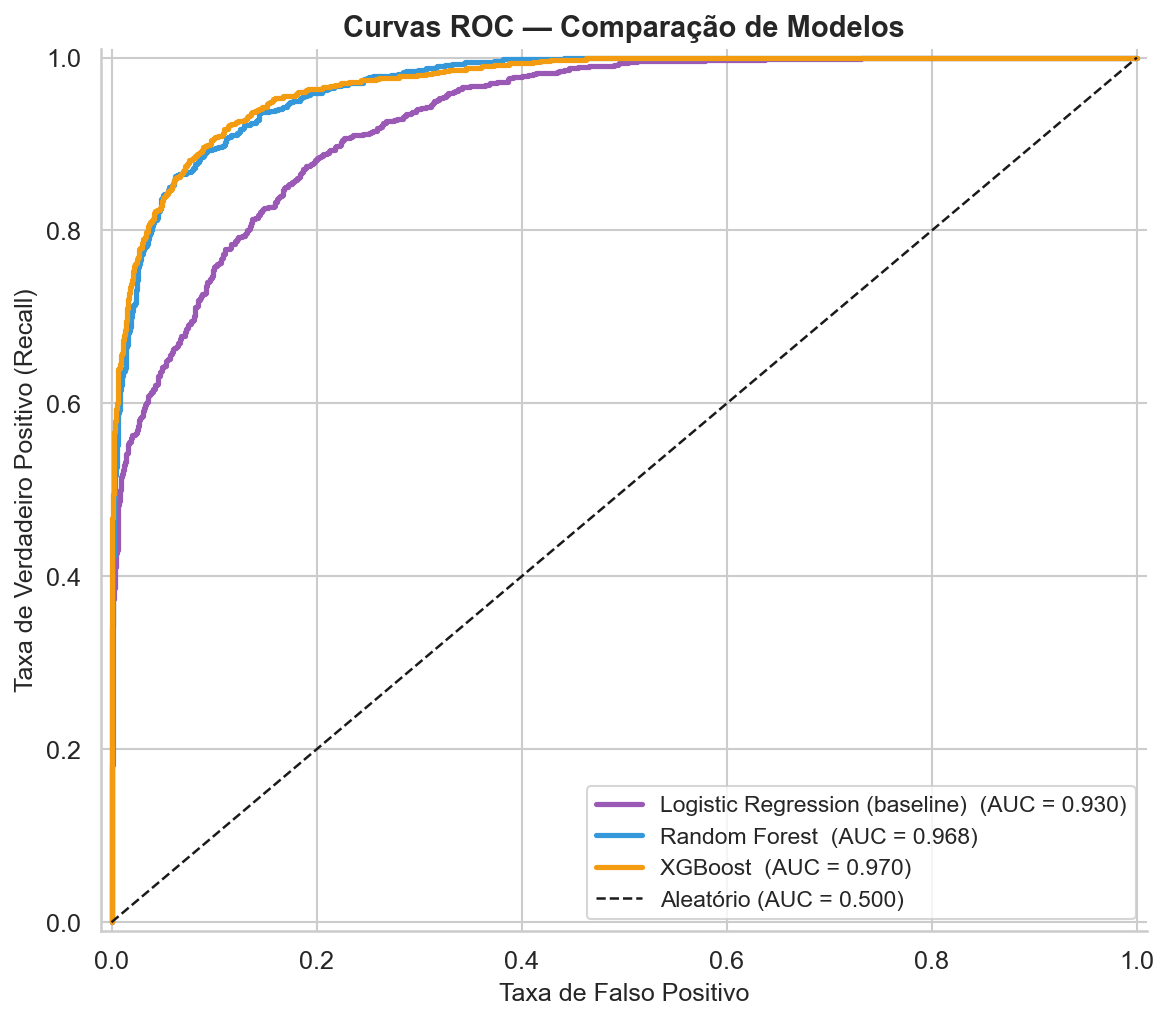

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Curvas ROC — Comparação de Modelos',
             fontsize=14, fontweight='bold')

for nome, cor in zip(nomes, cores_mod):
    y_proba = predicoes[nome]['proba']
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, color=cor, linewidth=2.5,
            label=f'{nome}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Aleatório (AUC = 0.500)')
ax.set_xlabel('Taxa de Falso Positivo', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiro Positivo (Recall)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
save_fig('08_curvas_roc')
plt.show()

## **Matrizes de Confusão:**

Salvo: ..\figures\09_matrizes_confusao.png


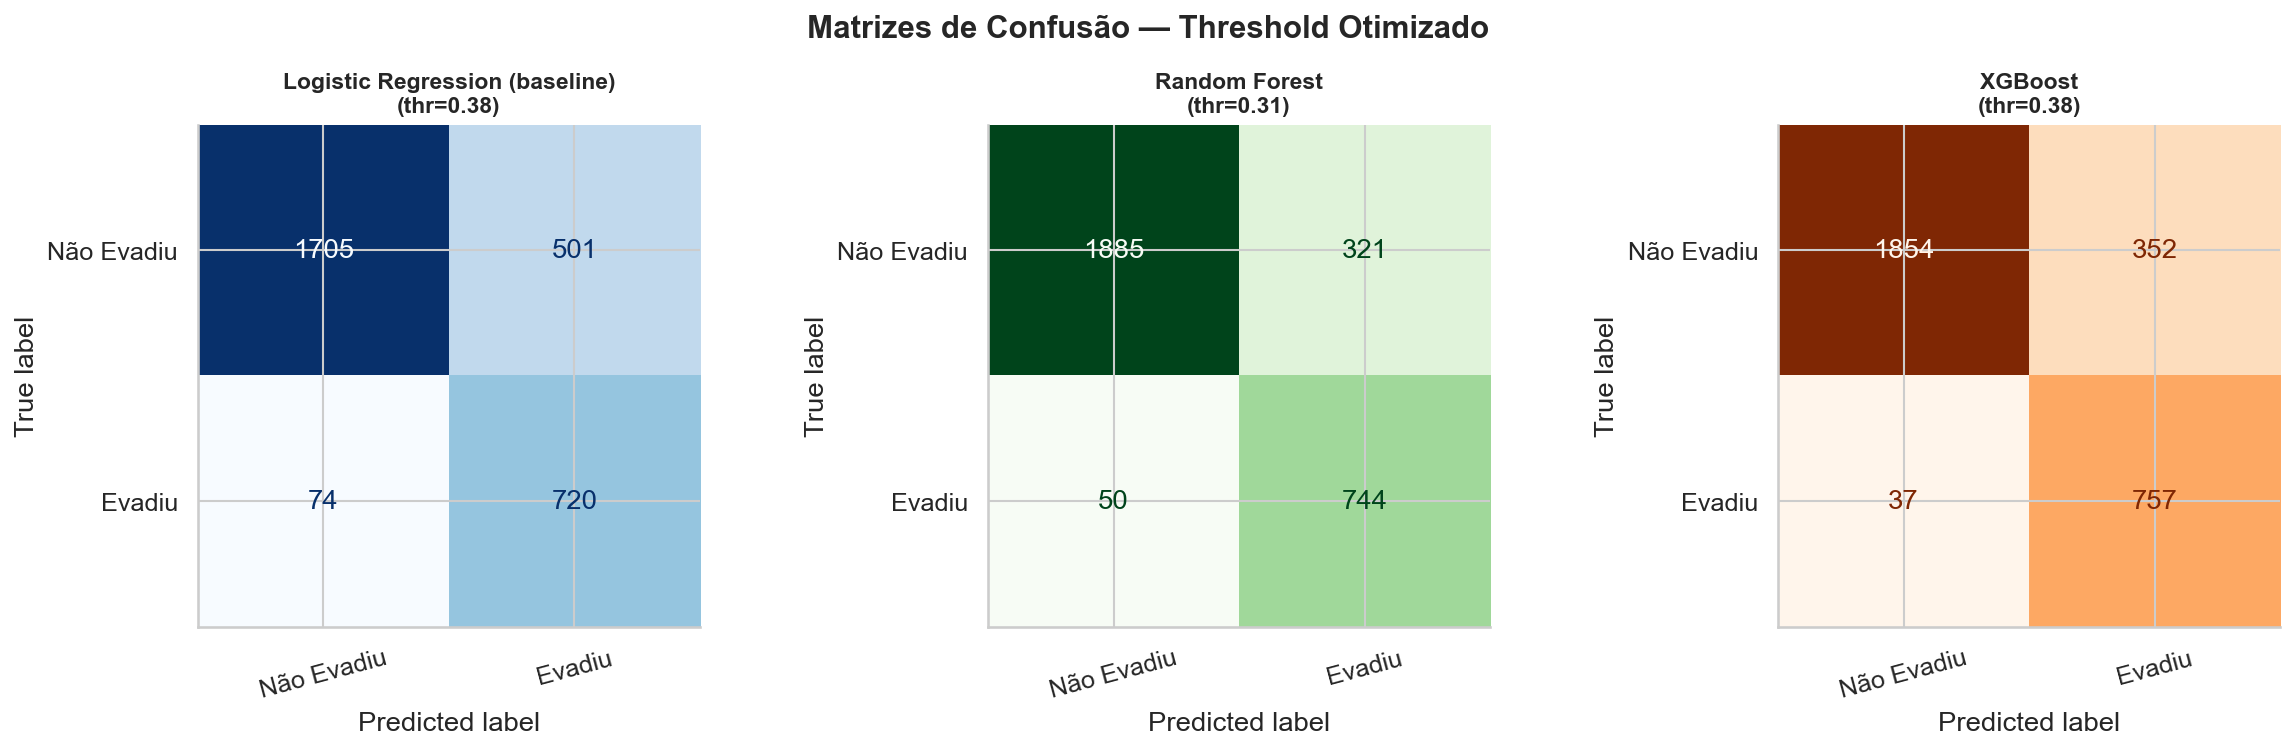

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Matrizes de Confusão — Threshold Otimizado',
             fontsize=15, fontweight='bold')

cmaps = ['Blues', 'Greens', 'Oranges']
for ax, nome, cmap in zip(axes, nomes, cmaps):
    y_pred = predicoes[nome]['pred']
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Não Evadiu', 'Evadiu']
    )
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='d')
    ax.set_title(f'{nome}\n(thr={thresholds[nome]:.2f})',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('09_matrizes_confusao')
plt.show()

## **Feature Importance — XGBoost:**

Salvo: ..\figures\10_feature_importance_xgb.png


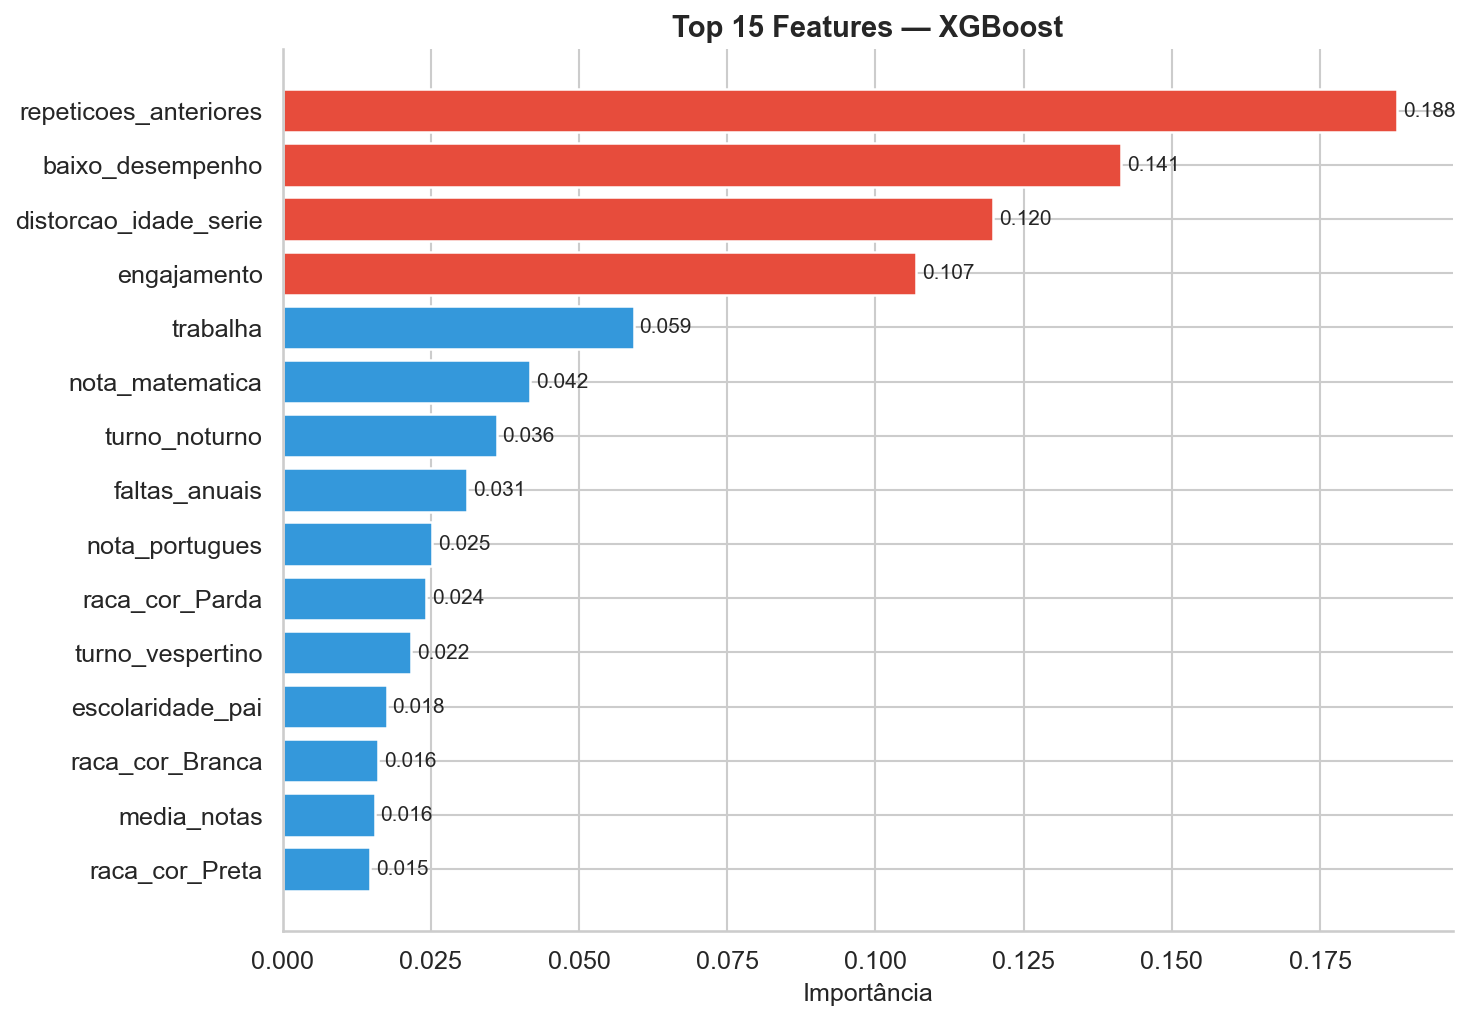

In [12]:
pipe_xgb  = modelos_treinados['XGBoost']
prep      = pipe_xgb.named_steps['prep']
clf_xgb   = pipe_xgb.named_steps['clf']

# Recuperar nomes das features após one-hot encoding
cat_names = prep.named_transformers_['cat'].get_feature_names_out(CAT_FEATURES)
all_names = np.array(NUM_FEATURES + list(cat_names))

importances = clf_xgb.feature_importances_
fi_df = pd.DataFrame({'feature': all_names, 'importance': importances})\
          .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title('Top 15 Features — XGBoost',
             fontsize=14, fontweight='bold')

cores_fi = [COLOR_ACCENT if v >= fi_df['importance'].quantile(0.75) else COLOR_RF
            for v in fi_df['importance']]
bars = ax.barh(fi_df['feature'], fi_df['importance'],
               color=cores_fi, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, fi_df['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Importância', fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
save_fig('10_feature_importance_xgb')
plt.show()

## **Salvar Modelo Final:**

In [13]:
# XGBoost foi o melhor modelo — salvar pipeline completo
modelo_final = modelos_treinados['XGBoost']
threshold_final = thresholds['XGBoost']

joblib.dump(modelo_final,       MODELS_DIR / 'pipeline_xgb.pkl')
joblib.dump(threshold_final,    MODELS_DIR / 'threshold_xgb.pkl')
df_resultados.to_csv(MODELS_DIR / 'resultados_modelos.csv', index=False)

print('Arquivos salvos:')
print(f'  {MODELS_DIR}/pipeline_xgb.pkl')
print(f'  {MODELS_DIR}/threshold_xgb.pkl')
print(f'  {MODELS_DIR}/resultados_modelos.csv')

Arquivos salvos:
  ..\models/pipeline_xgb.pkl
  ..\models/threshold_xgb.pkl
  ..\models/resultados_modelos.csv


## **Resumo Final:**

In [14]:
melhor = df_resultados.sort_values('F2-Score', ascending=False).iloc[0]

print(f"""
╔══════════════════════════════════════════════════════╗
║          RESULTADO FINAL — MODELO ESCOLHIDO          ║
╠══════════════════════════════════════════════════════╣
║  Modelo    : {melhor['Modelo']:<39}║
║  Threshold : {melhor['Threshold']:<39}║
╠══════════════════════════════════════════════════════╣
║  AUC-ROC   : {melhor['AUC-ROC']:<39}║
║  Recall    : {melhor['Recall']:<39}║
║  Precisão  : {melhor['Precisão']:<39}║
║  F1-Score  : {melhor['F1-Score']:<39}║
║  F2-Score  : {melhor['F2-Score']:<39}║
╠══════════════════════════════════════════════════════╣
║  - Recall = {melhor['Recall']:.1%} - o modelo identifica       ║
║    {melhor['Recall']:.1%} dos alunos em risco real de evasão.   ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║          RESULTADO FINAL — MODELO ESCOLHIDO          ║
╠══════════════════════════════════════════════════════╣
║  Modelo    : XGBoost                                ║
║  Threshold : 0.382                                  ║
╠══════════════════════════════════════════════════════╣
║  AUC-ROC   : 0.9702                                 ║
║  Recall    : 0.9534                                 ║
║  Precisão  : 0.6826                                 ║
║  F1-Score  : 0.7956                                 ║
║  F2-Score  : 0.8833                                 ║
╠══════════════════════════════════════════════════════╣
║  - Recall = 95.3% - o modelo identifica       ║
║    95.3% dos alunos em risco real de evasão.   ║
╚══════════════════════════════════════════════════════╝

